# Explorative Datenanalyse und Preprocessing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

c:\Users\markd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

print(df.head())

   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0


### Ausreißeranalyse

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_rows = []

for column_name in tqdm(numeric_columns, desc="Ermittle IQR-Ausreißer"):
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column_name] < lower_bound)
        | (df[column_name] > upper_bound)
    ).sum()

    outlier_rows.append({
        "Variable": column_name,
        "Untergrenze": round(lower_bound, 2),
        "Obergrenze": round(upper_bound, 2),
        "Ausreißer_Anzahl": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_rows)
print(outlier_summary)

Ermittle IQR-Ausreißer: 100%|██████████| 4/4 [00:00<00:00, 216.03it/s]

   Variable  Untergrenze  Obergrenze  Ausreißer_Anzahl
0  Duration        22.50       82.50                35
1     Pulse        83.50      127.50                18
2  Maxpulse        98.50      166.50                13
3  Calories        45.91      592.61                17


## Analyse der Verteilungen

### Verteilung der Trainingsdauer

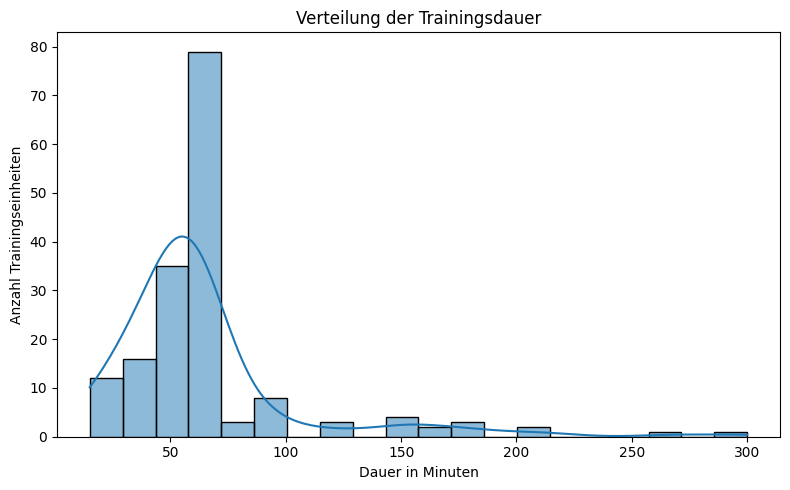

In [11]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Duration",
    bins=20,
    kde=True
)

plt.title("Verteilung der Trainingsdauer")
plt.xlabel("Dauer in Minuten")
plt.ylabel("Anzahl Trainingseinheiten")
plt.tight_layout()
plt.show()

### Verteilung des durschnittlichen Pulses

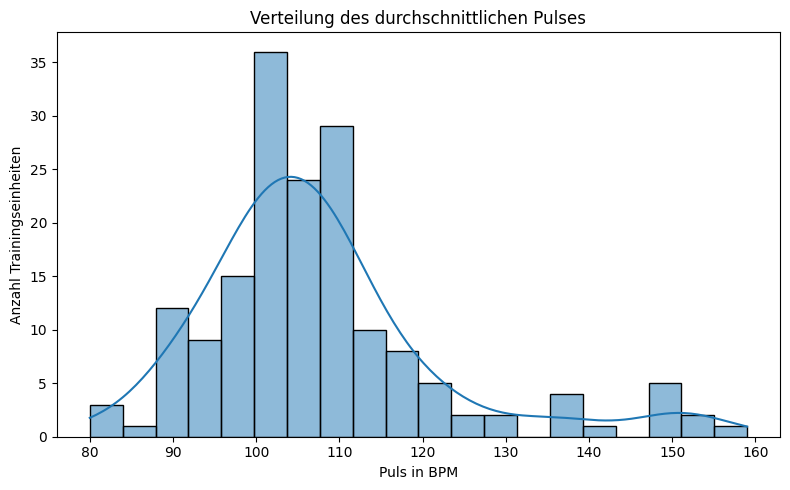

In [10]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Pulse",
    bins=20,
    kde=True
)

plt.title("Verteilung des durchschnittlichen Pulses")
plt.xlabel("Puls in BPM")
plt.ylabel("Anzahl Trainingseinheiten")
plt.tight_layout()
plt.show()

### Verteilung des maximalen Pulses

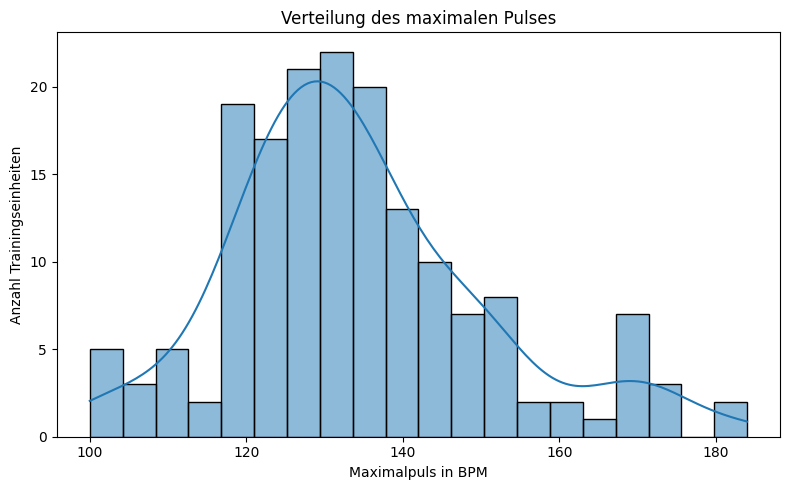

In [9]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Maxpulse",
    bins=20,
    kde=True
)

plt.title("Verteilung des maximalen Pulses")
plt.xlabel("Maximalpuls in BPM")
plt.ylabel("Anzahl Trainingseinheiten")
plt.tight_layout()
plt.show()

### Verteilung des Kalorienverbrauchs

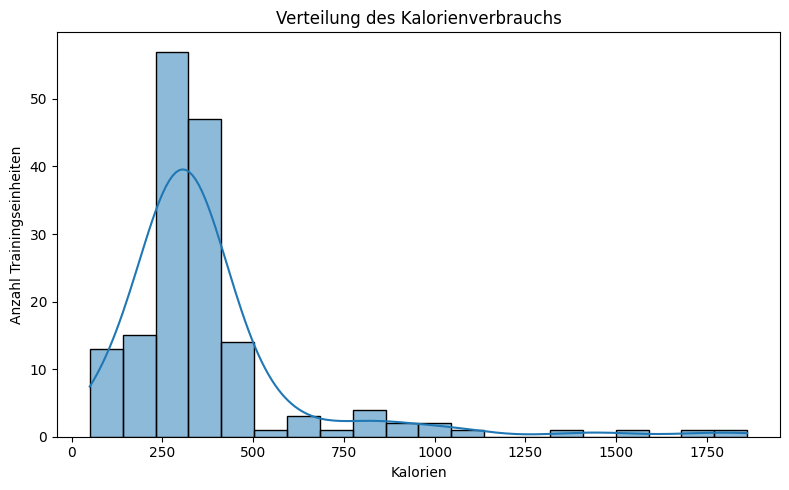

In [8]:
df = pd.read_csv('C:\\Users\\markd\\.vscode\\Fitness-exercise\\data\\raw\\data.csv')

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Calories",
    bins=20,
    kde=True
)

plt.title("Verteilung des Kalorienverbrauchs")
plt.xlabel("Kalorien")
plt.ylabel("Anzahl Trainingseinheiten")
plt.tight_layout()
plt.show()

### Korrelationsanalyse

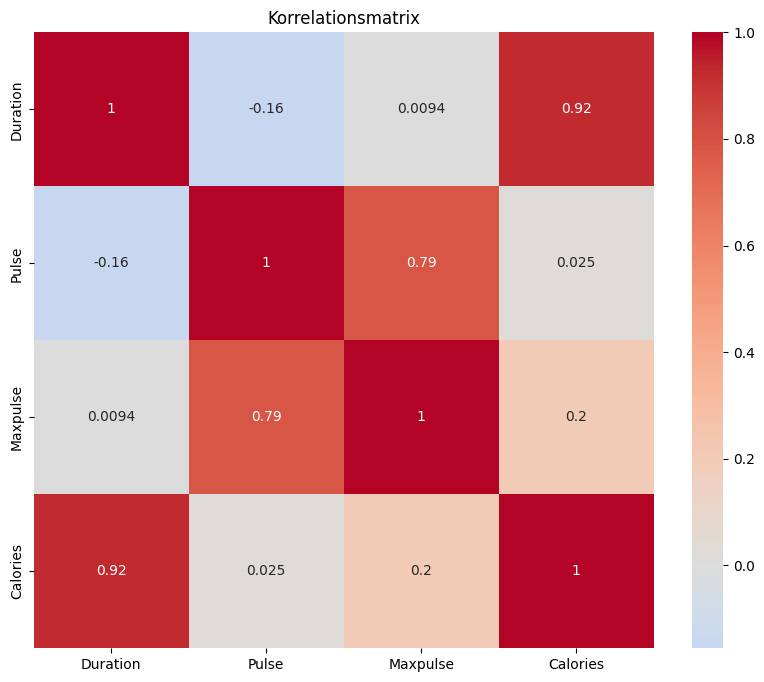

In [15]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Korrelationsmatrix')
plt.show()

### Trainingsdauer vs. Kalorienverbrauch

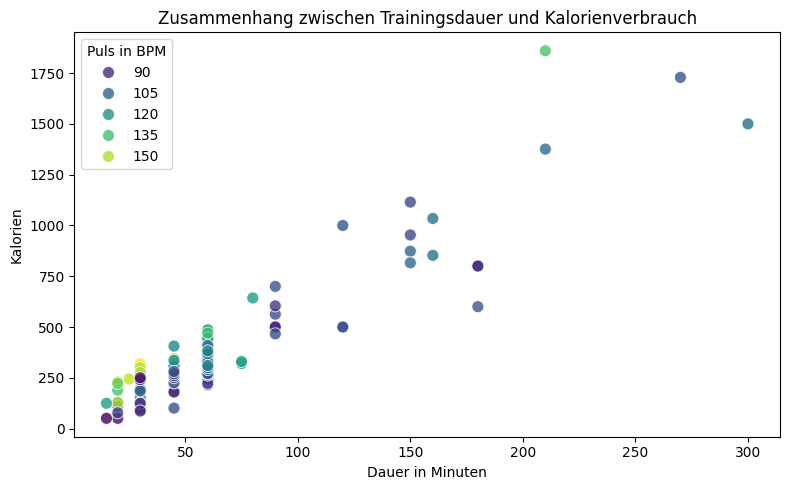

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Duration",
    y="Calories",
    hue="Pulse",
    palette="viridis",
    s=75,
    alpha=0.8
)

plt.title("Zusammenhang zwischen Trainingsdauer und Kalorienverbrauch")
plt.xlabel("Dauer in Minuten")
plt.ylabel("Kalorien")
plt.legend(title="Puls in BPM")
plt.tight_layout()
plt.show()

## Zusammenfassung der Analyse

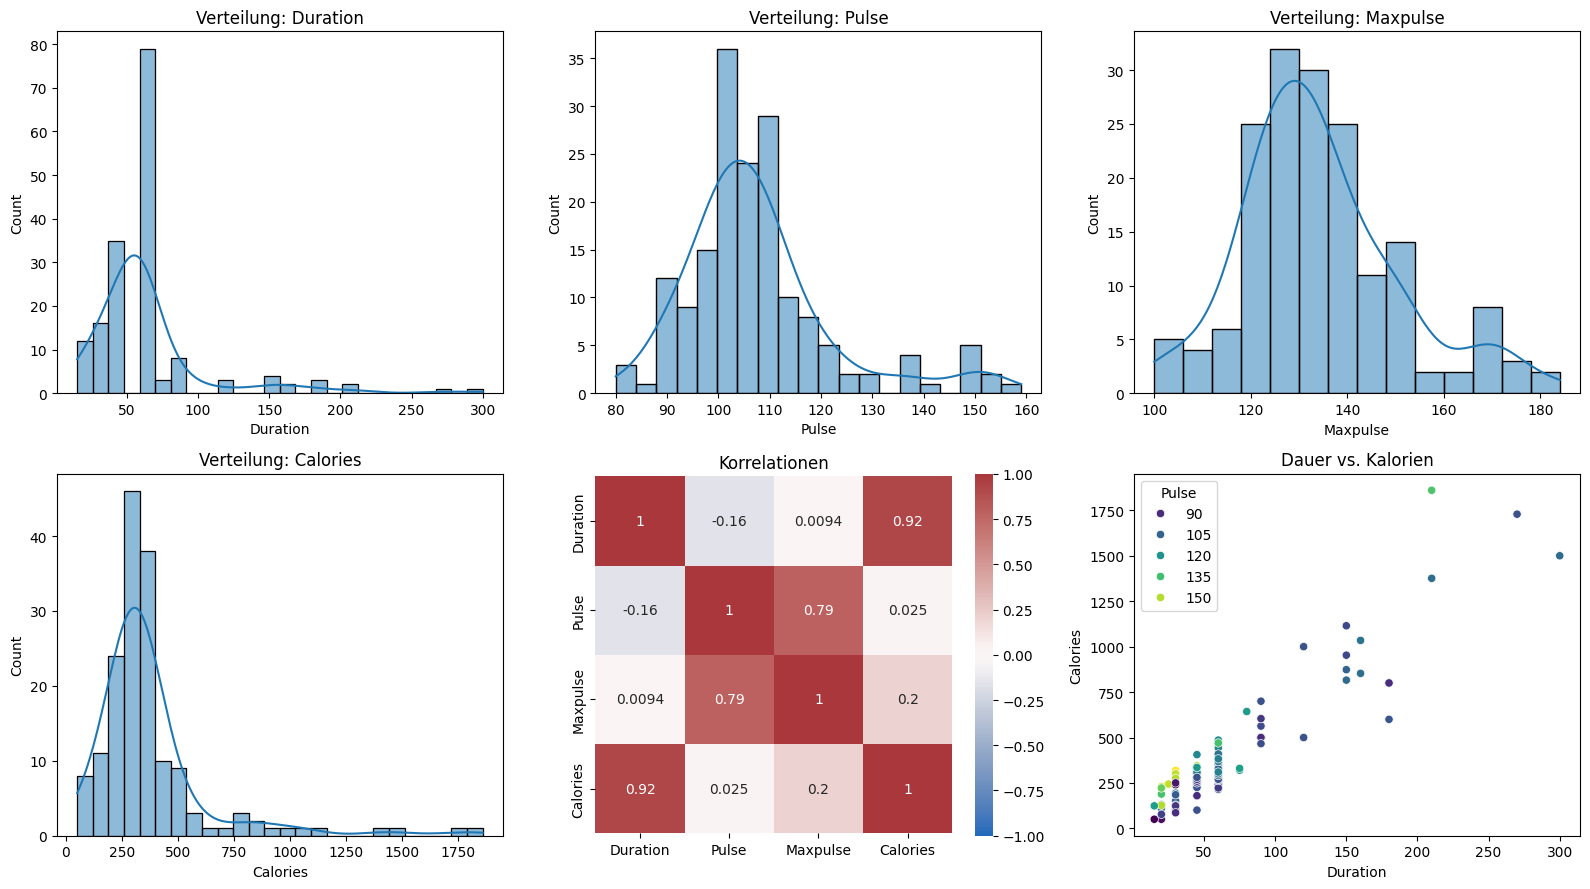

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for axis, column_name in zip(axes[:4], numeric_columns):
    sns.histplot(data=df, x=column_name, kde=True, ax=axis)
    axis.set_title(f"Verteilung: {column_name}")

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[4]
)
axes[4].set_title("Korrelationen")

sns.scatterplot(
    data=df,
    x="Duration",
    y="Calories",
    hue="Pulse",
    palette="viridis",
    ax=axes[5]
)
axes[5].set_title("Dauer vs. Kalorien")

plt.tight_layout()
plt.show()

## Preprocessing

### Kopie erstellen und Spalten umbenennen

In [7]:
clean_df = df.copy()

clean_df.columns = [
    "duration_min",
    "pulse_bpm",
    "max_pulse_bpm",
    "calories"
]

print(clean_df.head())

   duration_min  pulse_bpm  max_pulse_bpm  calories
0            60        110            130     409.1
1            60        117            145     479.0
2            60        103            135     340.0
3            45        109            175     282.4
4            45        117            148     406.0


### Doppelte Zeilen prüfen und entfernen

In [8]:
duplicate_count = clean_df.duplicated().sum()

print("Anzahl doppelter Zeilen vor der Bereinigung:", duplicate_count)

clean_df = clean_df.drop_duplicates().copy()

print("Anzahl der Zeilen nach dem Entfernen:", len(clean_df))

Anzahl doppelter Zeilen vor der Bereinigung: 7
Anzahl der Zeilen nach dem Entfernen: 162


### Unplausible Werte identifizieren und entfernen

In [9]:
value_columns = [
    "duration_min",
    "pulse_bpm",
    "max_pulse_bpm",
    "calories"
]

invalid_mask = (clean_df[value_columns] <= 0).any(axis=1)

print("Anzahl unplausibler Zeilen:", invalid_mask.sum())

clean_df = clean_df.loc[~invalid_mask].copy()

print("Anzahl der Zeilen nach Plausibilitätsprüfung:", len(clean_df))

Anzahl unplausibler Zeilen: 0
Anzahl der Zeilen nach Plausibilitätsprüfung: 162


### Fehlende Werte überprüfen und visualisieren

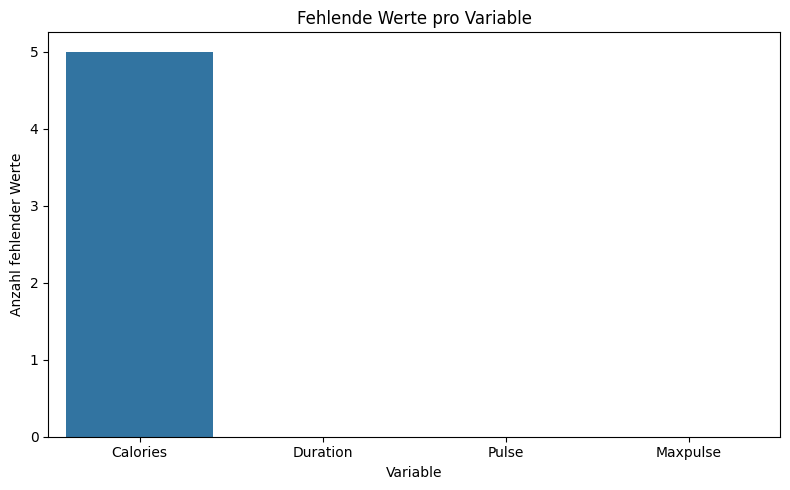

In [10]:
missing_values = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values,
    hue=missing_values.index,
    legend=False
)

plt.title("Fehlende Werte pro Variable")
plt.xlabel("Variable")
plt.ylabel("Anzahl fehlender Werte")
plt.tight_layout()
plt.show()

### Fehlende Kalorienwerte importieren

In [11]:
clean_df["calories_imputed"] = clean_df["calories"].isna().astype("int8")

calorie_median = clean_df["calories"].median()

print("Median der Kalorienwerte:", calorie_median)

clean_df["calories"] = clean_df["calories"].fillna(calorie_median)

print("Fehlende Werte nach Imputation:", clean_df["calories"].isna().sum())

Median der Kalorienwerte: 320.4
Fehlende Werte nach Imputation: 0


### Ausreißer für die Trainingsdauer markieren

In [12]:
q1 = clean_df["duration_min"].quantile(0.25)
q3 = clean_df["duration_min"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

clean_df["duration_min_outlier"] = (
    (clean_df["duration_min"] < lower_bound)
    | (clean_df["duration_min"] > upper_bound)
).astype("int8")

print("Markierte Ausreißer bei duration_min:")
print(clean_df["duration_min_outlier"].sum())

Markierte Ausreißer bei duration_min:
35
